In [2]:
import numpy as np
import torch
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from tqdm import tqdm
import os
import json
import matplotlib.pyplot as plt
from IPython.display import clear_output

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedAreaConfig, SpatiallyEmbeddedRNN
from bioplnn.datasets import Mazes

maze_data_path = "/om2/user/jackking/torch-bioplnn-dev/data/mazes"

In [3]:
# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")
# Set seed for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.2):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x, num_steps=None):  # num_steps parameter for compatibility
        # x shape: [batch_size, channels, height, width]
        x = self.pool(self.relu(self.conv1(x)))  # -> [batch_size, 32, 24, 24]
        x = self.pool(self.relu(self.conv2(x)))  # -> [batch_size, 64, 12, 12]
        x = self.pool(self.relu(self.conv3(x)))  # -> [batch_size, 128, 6, 6]
        x = x.view(-1, 128 * 6 * 6)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [5]:
# #works for 500 samples
#     model_config = {
#         "rnn_kwargs": {
#             "num_areas": 2,
#             "area_kwargs": [
#                 {
#                     "num_neuron_types": 2,
#                     "num_neuron_subtypes": np.array([64, 64]),
#                     "neuron_type_class": np.array(["excitatory", "inhibitory"]),
#                     "inter_neuron_type_connectivity": np.array(
#                         [[1, 1, 1], [1, 1, 1], [1, 1, 1]]
#                     ),
#                     "in_size": [48, 48],
#                     "in_channels": 4,
#                     "out_channels": 128,
#                 },
#                 {
#                     "num_neuron_types": 1,
#                     "num_neuron_subtypes": np.array([128]),
#                     "neuron_type_class": np.array(["excitatory"]),
#                     "inter_neuron_type_connectivity": np.array(
#                         [[1, 1], [1, 1]]
#                     ),
#                     "in_size": [48, 48],
#                     "in_channels": 128,
#                     "out_channels": 128,
#                 },
#             ],
#         },
#         "num_classes": 2,
#         "fc_dim": 128,
#         "dropout": 0.3,
#     }

#feedback examples
# model_config = {
#     "rnn_kwargs": {
#         "num_areas": 2,
#         "area_kwargs": [
#             {
#                 "num_neuron_types": 2,
#                 "num_neuron_subtypes": np.array([16, 16]),
#                 "neuron_type_class": np.array(["excitatory", "inhibitory"]),
#                 "inter_neuron_type_connectivity": np.array(
#                     [[1, 1, 0], [1, 0, 0],[1, 0, 1], [1, 0, 0]]
#                 ),
#                 "in_size": [48, 48],
#                 "in_channels": 4,
#                 "out_channels": 1,
#                 "feedback_channels": 1,
#             },
#             {
#                 "num_neuron_types": 1,
#                 "num_neuron_subtypes": np.array([4]),
#                 "neuron_type_class": np.array(["excitatory"]),
#                 "inter_neuron_type_connectivity": np.array(
#                     [[1, 0], [0, 1]]
#                 ),
#                 "in_size": [48, 48],
#                 "in_channels": 1,
#                 "out_channels": 1,
#             },
#         ],
#         "inter_area_feedback_connectivity": np.array([[0, 0], [1, 0]]),
#     },
#     "num_classes": 2,
#     "fc_dim": 32,
#     "dropout": 0.3,
# }

In [10]:
# Choose model type
model_type = "bioplnn"  # Options: "bioplnn" or "cnn"

if model_type == "bioplnn":
    model_config = {
        "rnn_kwargs": {
            "num_areas": 1,
            "area_kwargs": [
                {
                    "num_neuron_types": 2,
                    "num_neuron_subtypes": np.array([16, 16]),
                    "neuron_type_class": np.array(["excitatory", "inhibitory"]),
                    "inter_neuron_type_connectivity": np.array(
                        [[1, 1, 0], [1, 0, 1], [1, 0, 0]]
                    ),
                    "in_size": [48, 48],
                    "in_channels": 4,
                    "out_channels": 16,
                    "inter_neuron_type_nonlinearity": np.array([["relu", "relu", "relu"], ["relu", "relu", "relu"], ["relu", "relu", "relu"]]),
                    "inter_neuron_type_spatial_extents": (3, 3)
                }
            ],
        },
        "num_classes": 2,
        "fc_dim": 32,
        "dropout": 0.3,
    }
    model = SpatiallyEmbeddedClassifier(**model_config).to(device)
elif model_type == "cnn":
    model = SimpleCNN(in_channels=4, num_classes=2, dropout=0.2).to(device)
    model_config = {
        "in_channels": 4,
        "num_classes": 2,
        "architecture": "SimpleCNN",
        "dropout": 0.2,
    }
else:
    raise ValueError(f"Unknown model type: {model_type}")

print(sum(p.numel() for p in model.parameters()))

8786


In [6]:
#print the number of parameteres in every layer
print(model)
for name, param in model.named_parameters():
    print(name, param.numel())

SpatiallyEmbeddedClassifier(
  (rnn): SpatiallyEmbeddedRNN(
    (areas): ModuleList(
      (0): SpatiallyEmbeddedArea(
        (out_nonlinearity): Identity()
        (neuron_type_nonlinearity): ModuleList(
          (0-1): 2 x Sigmoid()
        )
        (convs): ModuleDict(
          (0->0): Sequential(
            (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU()
          )
          (0->1): Sequential(
            (0): Conv2d(4, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU()
          )
          (1->0): Sequential(
            (0): Conv2dRectify(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU()
          )
          (2->0): Sequential(
            (0): Conv2dRectify(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): ReLU()
          )
        )
        (out_convs): ModuleDict(
          (1->out): Sequential(
            (0): Conv2dRectify(16, 16, ke

In [5]:
# Define the optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Define the loss function
criterion = nn.CrossEntropyLoss()

#Def num_steps
num_steps = 20

In [7]:
len(mazes)

345600

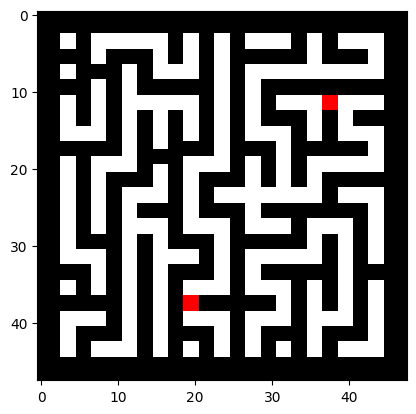

In [6]:
def visualize_maze(mazes, index):
    maze, maze_data = mazes[index]
    image = mazes.tensor_to_image(maze)
    plt.imshow(image)
    plt.show()
mazes = Mazes(maze_data_path)
visualize_maze(mazes, 7)

In [9]:
class MazeDataset(torch.utils.data.Dataset):
    def __init__(self, maze_data_path, transform=None):
        self.mazes = Mazes(maze_data_path)
        self.transform = transform
        
    def __len__(self):
        return len(self.mazes)
    
    def __getitem__(self, idx):
        maze, label = self.mazes[idx]
        if self.transform:
            maze = self.transform(maze)
        return maze, label

In [10]:
maze_dataset = MazeDataset(maze_data_path)
num_samples = 20000
if num_samples is None:
    num_samples = len(maze_dataset)
indices = torch.randperm(len(maze_dataset))[:num_samples].tolist()
maze_dataset = torch.utils.data.Subset(maze_dataset, indices)

# Split dataset into train and test sets
train_size = int(0.8 * num_samples)
test_size = num_samples - train_size
train_dataset, test_dataset = torch.utils.data.random_split(maze_dataset, [train_size, test_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [2]:
# Define evaluation function
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for x, labels in data_loader:
            x = x.to(device)
            labels = labels.to(device)
            
            logits = model(x, num_steps=num_steps)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / len(data_loader)
    accuracy = correct / total
    model.train()
    return avg_loss, accuracy

def plot_training_metrics(train_losses, train_accuracies, val_losses, val_accuracies):
    clear_output(wait=True)
    
    # Create a single figure with all metrics
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    
    # Training metrics
    axs[0, 0].plot(train_losses, label='Training Loss')
    axs[0, 0].set_xlabel('Iteration')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].set_title('Training Loss')
    axs[0, 0].legend()
    
    axs[0, 1].plot(train_accuracies, label='Training Accuracy')
    axs[0, 1].set_xlabel('Iteration')
    axs[0, 1].set_ylabel('Accuracy')
    axs[0, 1].set_title('Training Accuracy')
    axs[0, 1].legend()
    
    # Validation metrics
    axs[1, 0].plot(val_losses, label='Validation Loss')
    axs[1, 0].set_xlabel('Iteration')
    axs[1, 0].set_ylabel('Loss')
    axs[1, 0].set_title('Validation Loss')
    axs[1, 0].legend()
    
    axs[1, 1].plot(val_accuracies, label='Validation Accuracy')
    axs[1, 1].set_xlabel('Iteration')
    axs[1, 1].set_ylabel('Accuracy')
    axs[1, 1].set_title('Validation Accuracy')
    axs[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

# Define the training loop



model.train()
n_epochs = 500
train_log_frequency = len(train_loader) #max(len(train_loader) // 10, 1)  # How often to log training metrics
evaluate_frequency = len(train_loader) # How often to evaluate on validation set
print(len(train_loader))

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

plt.ion()  # turn on interactive mode

running_loss, running_correct, running_total = 0, 0, 0
for epoch in range(n_epochs):
    for i, (x, labels) in enumerate(tqdm(train_loader)):
        x = x.to(device)
        labels = labels.to(device)
        torch._inductor.cudagraph_mark_step_begin()
        logits = model(x, num_steps=num_steps)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate running accuracy and loss
        _, predicted = torch.max(logits, 1)
        running_total += labels.size(0)
        running_correct += (predicted == labels).sum().item()
        running_loss += loss.item()

        # Log training metrics
        if (i + 1) % train_log_frequency == 0:
            print(
                f"Training | Epoch: {epoch} | "
                + f"Loss: {running_loss / running_total:.4f} | "
                + f"Acc: {running_correct / running_total:.2%}"
            )
            
            train_losses.append(running_loss / running_total)
            train_accuracies.append(running_correct / running_total)
            running_loss, running_correct, running_total = 0, 0, 0
            plot_training_metrics(train_losses, train_accuracies, val_losses, val_accuracies)

        # Evaluate on validation set
        if (i + 1) % evaluate_frequency == 0:
            val_loss, val_acc = evaluate(model, test_loader, criterion, device)
            val_losses.append(val_loss)
            val_accuracies.append(val_acc)
            plot_training_metrics(train_losses, train_accuracies, val_losses, val_accuracies)

NameError: name 'model' is not defined

In [2]:
import numpy as np
import torch
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from tqdm import tqdm
import os
import json
import matplotlib.pyplot as plt
from IPython.display import clear_output
import wandb
import psutil
import GPUtil
wandb.login(key="a338f755915cccd861b14f29bf68601d8e1ec2c9")

from bioplnn.models import SpatiallyEmbeddedClassifier
from bioplnn.datasets import Mazes

maze_data_path = "/om2/user/jackking/torch-bioplnn-dev/data/mazes"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

BATCH_SIZE = 32

class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.2):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x, num_steps=None):  # num_steps parameter for compatibility
        # x shape: [batch_size, channels, height, width]
        x = self.pool(self.relu(self.conv1(x)))  # -> [batch_size, 32, 24, 24]
        x = self.pool(self.relu(self.conv2(x)))  # -> [batch_size, 64, 12, 12]
        x = self.pool(self.relu(self.conv3(x)))  # -> [batch_size, 128, 6, 6]
        x = x.view(-1, 128 * 6 * 6)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class MazeDataset(torch.utils.data.Dataset):
    def __init__(self, maze_data_path, transform=None):
        self.mazes = Mazes(maze_data_path)
        self.transform = transform
        
    def __len__(self):
        return len(self.mazes)
    
    def __getitem__(self, idx):
        maze, label = self.mazes[idx]
        print(maze.shape)
        maze = torch.stack([maze[0], maze[-1]])
        print(maze.shape)
        if self.transform:
            maze = self.transform(maze)
        return maze, label

def load_data(batch_size=BATCH_SIZE, num_samples=None):
    # Create the dataset
    maze_dataset = MazeDataset(maze_data_path)
    if num_samples is None:
        num_samples = len(maze_dataset)
    indices = torch.randperm(len(maze_dataset))[:num_samples].tolist()
    maze_dataset = torch.utils.data.Subset(maze_dataset, indices)
    input, label = maze_dataset[0]
    print(label)
    plt.imshow(input[0].numpy() + input[1].numpy())

load_data()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/jackking/.netrc


torch.Size([4, 48, 48])


TypeError: stack(): argument 'tensors' (position 1) must be tuple of Tensors, not Tensor

In [3]:
data = Mazes(maze_data_path)

In [11]:
len(data[0][0])

4